라이브러리 import 및 경로 설정

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

# 경로 설정
BASE_DIR = Path("C:/Users/seonu/Documents/DR-project")
DATA_DIR = BASE_DIR / "data"

ENERGY_DIR = DATA_DIR / "energy"
POP_DIR = DATA_DIR / "population"
MAPPING_DIR = DATA_DIR / "mapping"

print("경로 설정 완료")

경로 설정 완료


 행정동 매핑 테이블 로드

In [8]:
# 행정동 코드 매핑 로드
mapping = pd.read_excel(
    MAPPING_DIR / "행정동코드_매핑정보_20241218.xlsx",
    sheet_name="행정동코드",
    header=1  # 2번째 행이 실제 컬럼명 (H_SDNG_CD, H_DNG_CD 등)
)

# 필요한 컬럼만 선택 + 이름 정리
mapping = mapping[["H_DNG_CD", "CT_NM", "H_DNG_NM"]].copy()
mapping.columns = ["행정동코드", "자치구명", "행정동명"]
mapping["행정동코드"] = mapping["행정동코드"].astype(str)

print(mapping.shape)
print(mapping.head())

(424, 3)
      행정동코드 자치구명 행정동명
0  11110530  종로구  사직동
1  11110540  종로구  삼청동
2  11110550  종로구  부암동
3  11110560  종로구  평창동
4  11110570  종로구  무악동


전력 데이터 로드

In [9]:
# seoul_energy_total.xlsx 사용 (전체 합본)
energy = pd.read_excel(ENERGY_DIR / "seoul_energy_total.xlsx")

print(energy.shape)
print(energy.head())
print(energy.columns.tolist())

(3416, 17)
   번호    연도 자치구명  행정동명             계            1월            2월  \
0   1  2018   총합    총합  4.272368e+07  3.993222e+06  3.984320e+06   
1   2  2018  강남구  개포1동  1.641712e+04  1.480501e+03  1.540531e+03   
2   3  2018  강남구  개포2동  3.640540e+04  3.476433e+03  3.529326e+03   
3   4  2018  강남구  개포3동  1.442216e+05  1.745106e+04  1.664378e+04   
4   5  2018  강남구  개포4동  6.773545e+04  6.783491e+03  7.380690e+03   

             3월            4월            5월            6월            7월  \
0  3.251934e+06  3.115864e+06  2.993266e+06  3.295448e+06  3.827038e+06   
1  1.247099e+03  1.256282e+03  1.141569e+03  1.202000e+03  1.481455e+03   
2  2.793599e+03  2.599001e+03  2.416251e+03  2.640655e+03  3.213882e+03   
3  1.475214e+04  1.179961e+04  9.798013e+03  8.487930e+03  9.533584e+03   
4  5.595312e+03  4.983459e+03  4.365550e+03  4.693713e+03  5.436982e+03   

             8월            9월           10월           11월           12월  
0  4.875834e+06  3.816125e+06  2.965608e+06  3.083785e+

총합 행(첫 번째 행)은 분석에 필요 없으니 제거하고, 매핑 테이블이랑 조인

전력 데이터 전처리 및 매핑 조인

In [10]:
# 총합 행 제거
energy_clean = energy[energy["행정동명"] != "총합"].copy()

# 자치구명 + 행정동명으로 매핑 조인
energy_merged = energy_clean.merge(
    mapping,
    on=["자치구명", "행정동명"],
    how="left"
)

# 조인 결과 확인
total = len(energy_merged)
matched = energy_merged["행정동코드"].notna().sum()
unmatched = energy_merged["행정동코드"].isna().sum()

print(f"전체: {total}행")
print(f"매칭 성공: {matched}행")
print(f"매칭 실패: {unmatched}행")

# 매칭 실패한 행정동 확인
if unmatched > 0:
    fail = energy_merged[energy_merged["행정동코드"].isna()][["연도","자치구명","행정동명"]].drop_duplicates()
    print("\n매칭 실패 목록:")
    print(fail.to_string())

전체: 3408행
매칭 성공: 1944행
매칭 실패: 1464행

매칭 실패 목록:
        연도  자치구명     행정동명
2     2018   강남구     개포3동
23    2018   강동구    고덕제1동
24    2018   강동구    고덕제2동
26    2018   강동구    둔촌제1동
27    2018   강동구    둔촌제2동
28    2018   강동구    명일제1동
29    2018   강동구    명일제2동
30    2018   강동구     상일1동
31    2018   강동구     상일2동
32    2018   강동구    성내제1동
33    2018   강동구    성내제2동
34    2018   강동구    성내제3동
35    2018   강동구    암사제1동
36    2018   강동구    암사제2동
37    2018   강동구    암사제3동
38    2018   강동구    천호제1동
39    2018   강동구    천호제2동
40    2018   강동구    천호제3동
54    2018   강서구    가양제1동
55    2018   강서구    가양제2동
56    2018   강서구    가양제3동
58    2018   강서구    등촌제1동
59    2018   강서구    등촌제2동
60    2018   강서구    등촌제3동
61    2018   강서구    발산제1동
62    2018   강서구    방화제1동
63    2018   강서구    방화제2동
64    2018   강서구    방화제3동
68    2018   강서구    화곡제1동
69    2018   강서구    화곡제2동
70    2018   강서구    화곡제3동
71    2018   강서구    화곡제4동
72    2018   강서구    화곡제6동
73    2018   강서구    화곡제8동
96    2018   광진구    구의제1동
97    2018   광진구 

원인

전력 데이터: 고덕제1동, 둔촌제1동, 성내제1동 → "제"가 들어가 있음


매핑 테이블: 고덕1동, 둔촌1동, 성내1동 → "제" 없음

행정동명 정제 후 재조인

In [11]:
# 전력 데이터 행정동명에서 "제" 제거
energy_clean["행정동명_정제"] = energy_clean["행정동명"].str.replace("제", "", regex=False)

# 매핑도 동일하게 정제 컬럼 추가
mapping["행정동명_정제"] = mapping["행정동명"].str.replace("제", "", regex=False)

# 정제된 이름으로 재조인
energy_merged2 = energy_clean.merge(
    mapping[["행정동코드", "자치구명", "행정동명_정제"]],
    on=["자치구명", "행정동명_정제"],
    how="left"
)

total = len(energy_merged2)
matched = energy_merged2["행정동코드"].notna().sum()
unmatched = energy_merged2["행정동코드"].isna().sum()

print(f"전체: {total}행")
print(f"매칭 성공: {matched}행")
print(f"매칭 실패: {unmatched}행")

if unmatched > 0:
    fail = energy_merged2[energy_merged2["행정동코드"].isna()][["연도","자치구명","행정동명"]].drop_duplicates()
    print("\n매칭 실패 목록:")
    print(fail.to_string())

전체: 3408행
매칭 성공: 3376행
매칭 실패: 32행

매칭 실패 목록:
        연도 자치구명  행정동명
2     2018  강남구  개포3동
30    2018  강동구  상일1동
31    2018  강동구  상일2동
125   2018  구로구    항동
428   2019  강남구  개포3동
456   2019  강동구  상일1동
457   2019  강동구  상일2동
551   2019  구로구    항동
854   2020  강남구  개포3동
882   2020  강동구  상일1동
883   2020  강동구  상일2동
977   2020  구로구    항동
1280  2021  강남구  개포3동
1308  2021  강동구  상일1동
1309  2021  강동구  상일2동
1403  2021  구로구    항동
1706  2022  강남구  개포3동
1734  2022  강동구  상일1동
1735  2022  강동구  상일2동
1829  2022  구로구    항동
2132  2023  강남구  개포3동
2160  2023  강동구  상일1동
2161  2023  강동구  상일2동
2255  2023  구로구    항동
2558  2024  강남구  개포3동
2586  2024  강동구  상일1동
2587  2024  강동구  상일2동
2681  2024  구로구    항동
2984  2025  강남구  개포3동
3012  2025  강동구  상일1동
3013  2025  강동구  상일2동
3107  2025  구로구    항동


3개 행정동 매핑 실패

개포3동 → 매핑에서 확인 필요

상일1동, 상일2동 → 매핑에 없는 동 (신설동일 가능성)

항동 → 2020년 신설 행정동이라 매핑에 없을 수 있음

미매칭 3개 행정동 직접 확인

In [12]:
# 매핑에서 관련 행정동 검색
search_list = ["개포", "상일", "항동"]
for keyword in search_list:
    result = mapping[mapping["행정동명"].str.contains(keyword)]
    print(f"\n[{keyword}] 검색 결과:")
    print(result)


[개포] 검색 결과:
        행정동코드 자치구명  행정동명 행정동명_정제
368  11680660  강남구  개포1동    개포1동
369  11680690  강남구  개포4동    개포4동
378  11680670  강남구  개포2동    개포2동

[상일] 검색 결과:
        행정동코드 자치구명 행정동명 행정동명_정제
407  11740520  강동구  상일동     상일동

[항동] 검색 결과:
        행정동코드 자치구명 행정동명 행정동명_정제
254  11500620  강서구  공항동     공항동


개포3동 → 매핑에 아예 없음 (2009년 개포2동에 통합되며 폐지됐지만 2022년 12월23일 강남구 일원2동이 개포3동으로 명칭변경, 개포3동 정상 운영)

상일1동, 상일2동 → 매핑엔 상일동 하나만 있음 (상일1동과 상일2동은 2021년 7월 1일에 분동됨)

항동 → 매핑에 없음 (2020년 1월 1일에 행정동으로 추가·신설됨)

>생활인구 데이터는 데이터 일관성 유지를 위해 2016년 집계구, 행정동 코드를 사용하고 있어 2020년에 추가된 행정동이 없습니다. 데이터 일관성 유지를 위해 집계 영역을 변경할 수 없으니 참고 바랍니다.

현실적인 처리 방안:

전력: 개포3동 → 생활인구 코드: 일원2동 코드

전력: 상일1동 + 상일2동 합산 → 생활인구 코드: 상일동 코드

전력: 항동 → 제외 (32행 중 8행, 전체의 0.2%)


수동 매핑 처리

In [13]:
# 상일1동 + 상일2동 전력 합산 후 상일동으로 처리
# 먼저 상일동 코드 확인
sangil_code = mapping[mapping["행정동명"] == "상일동"]["행정동코드"].values[0]
ilwon2_code = mapping[mapping["행정동명"] == "일원2동"]["행정동코드"].values[0]

print(f"상일동 코드: {sangil_code}")
print(f"일원2동 코드: {ilwon2_code}")

# 수동 매핑 적용
# 개포3동 → 일원2동 코드
mask_gaepо3 = (energy_merged2["행정동코드"].isna()) & (energy_merged2["행정동명"] == "개포3동")
energy_merged2.loc[mask_gaepо3, "행정동코드"] = ilwon2_code

# 상일1동, 상일2동 → 상일동 코드
mask_sangil = (energy_merged2["행정동코드"].isna()) & (energy_merged2["행정동명"].isin(["상일1동", "상일2동"]))
energy_merged2.loc[mask_sangil, "행정동코드"] = sangil_code

# 항동 제외
energy_final = energy_merged2[energy_merged2["행정동명"] != "항동"].copy()

# 최종 확인
unmatched_final = energy_final["행정동코드"].isna().sum()
print(f"\n최종 매칭 실패: {unmatched_final}행")
print(f"최종 데이터 행 수: {len(energy_final)}")
print(f"매칭 성공률: {(1 - unmatched_final/len(energy_final))*100:.1f}%")

상일동 코드: 11740520
일원2동 코드: 11680740

최종 매칭 실패: 0행
최종 데이터 행 수: 3400
매칭 성공률: 100.0%


wide → long 변환

조인을 위해 1월~12월 칼럼을 행으로 바꾸기

In [14]:
# 월 컬럼 long 형태로 변환
month_cols = ['1월','2월','3월','4월','5월','6월','7월','8월','9월','10월','11월','12월']

energy_long = energy_final.melt(
    id_vars=["연도", "자치구명", "행정동명", "행정동코드"],
    value_vars=month_cols,
    var_name="월",
    value_name="전력사용량"
)

# 월 컬럼 숫자로 변환 (1월 → 1)
energy_long["월"] = energy_long["월"].str.replace("월", "").astype(int)

# 정렬
energy_long = energy_long.sort_values(["행정동코드", "연도", "월"]).reset_index(drop=True)

print(energy_long.shape)
print(energy_long.head(10))

(40800, 6)
     연도 자치구명   행정동명     행정동코드   월     전력사용량
0  2018  종로구  청운효자동  11110515   1  4128.255
1  2018  종로구  청운효자동  11110515   2  4278.667
2  2018  종로구  청운효자동  11110515   3  3247.733
3  2018  종로구  청운효자동  11110515   4  3014.901
4  2018  종로구  청운효자동  11110515   5  2643.898
5  2018  종로구  청운효자동  11110515   6  2820.127
6  2018  종로구  청운효자동  11110515   7  3217.121
7  2018  종로구  청운효자동  11110515   8  4303.743
8  2018  종로구  청운효자동  11110515   9  3476.465
9  2018  종로구  청운효자동  11110515  10  2543.091


생활인구 데이터 로드 (파일럿: 2023년 1월)

In [15]:
sample = pd.read_csv(
    POP_DIR / "LOCAL_PEOPLE_DONG_202301.csv")

sample.info()

<class 'pandas.DataFrame'>
Index: 315456 entries, 20230101 to 20230131
Data columns (total 32 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   기준일ID            315456 non-null  int64  
 1   시간대구분            315456 non-null  int64  
 2   행정동코드            315456 non-null  float64
 3   총생활인구수           315456 non-null  float64
 4   남자0세부터9세생활인구수    315456 non-null  float64
 5   남자10세부터14세생활인구수  315456 non-null  float64
 6   남자15세부터19세생활인구수  315456 non-null  float64
 7   남자20세부터24세생활인구수  315456 non-null  float64
 8   남자25세부터29세생활인구수  315456 non-null  float64
 9   남자30세부터34세생활인구수  315456 non-null  float64
 10  남자35세부터39세생활인구수  315456 non-null  float64
 11  남자40세부터44세생활인구수  315456 non-null  float64
 12  남자45세부터49세생활인구수  315456 non-null  float64
 13  남자50세부터54세생활인구수  315456 non-null  float64
 14  남자55세부터59세생활인구수  315456 non-null  float64
 15  남자60세부터64세생활인구수  315456 non-null  float64
 16  남자65세부터69세생활인구수  315456 non-null  float64
 17

생활인구 2023년 1,12월 로드 및 전처리

In [16]:
use_cols = ["기준일ID", "시간대구분", "행정동코드", "총생활인구수"]

pop_jan = pd.read_csv(POP_DIR / "LOCAL_PEOPLE_DONG_202301.csv", encoding="utf-8", index_col=False)
pop_dec = pd.read_csv(POP_DIR / "LOCAL_PEOPLE_DONG_202312.csv", encoding="utf-8", index_col=False)

pop = pd.concat([pop_jan, pop_dec], ignore_index=True)
pop = pop[use_cols].copy()

# 타입 정리
pop["행정동코드"] = pop["행정동코드"].astype(int).astype(str)
pop["기준일ID"] = pop["기준일ID"].astype(str)
pop["연도"] = pop["기준일ID"].str[:4].astype(int)
pop["월"] = pop["기준일ID"].str[4:6].astype(int)

print(pop.shape)
print(pop.head())

(630912, 6)
      기준일ID  시간대구분     행정동코드      총생활인구수    연도  월
0  20230101      0  11620655  20101.7019  2023  1
1  20230101      0  11740515  53691.8435  2023  1
2  20230101      0  11650621  25383.1167  2023  1
3  20230101      0  11650580  20984.6421  2023  1
4  20230101      0  11305630  31798.8229  2023  1


시간대별 비율 계산

In [17]:
# 행정동별 월별 시간대별 총생활인구 합산
pop_hourly = pop.groupby(["행정동코드", "연도", "월", "시간대구분"])["총생활인구수"].sum().reset_index()

# 행정동별 월별 전체 합산
pop_monthly_total = pop_hourly.groupby(["행정동코드", "연도", "월"])["총생활인구수"].sum().reset_index()
pop_monthly_total.columns = ["행정동코드", "연도", "월", "월별총인구"]

# 비율 계산
pop_ratio = pop_hourly.merge(pop_monthly_total, on=["행정동코드", "연도", "월"])
pop_ratio["시간대비율"] = pop_ratio["총생활인구수"] / pop_ratio["월별총인구"]

print(pop_ratio.shape)
print(pop_ratio.head(10))
print(f"\n비율 합계 검증 (1.0이면 정상):")
print(pop_ratio.groupby(["행정동코드", "연도", "월"])["시간대비율"].sum().describe())

(20352, 7)
      행정동코드    연도  월  시간대구분       총생활인구수         월별총인구     시간대비율
0  11110515  2023  1      0  473484.4645  1.238645e+07  0.038226
1  11110515  2023  1      1  477423.0105  1.238645e+07  0.038544
2  11110515  2023  1      2  479292.9455  1.238645e+07  0.038695
3  11110515  2023  1      3  479819.2919  1.238645e+07  0.038737
4  11110515  2023  1      4  480626.0252  1.238645e+07  0.038803
5  11110515  2023  1      5  480163.3235  1.238645e+07  0.038765
6  11110515  2023  1      6  489921.9889  1.238645e+07  0.039553
7  11110515  2023  1      7  503153.8669  1.238645e+07  0.040621
8  11110515  2023  1      8  518157.4299  1.238645e+07  0.041833
9  11110515  2023  1      9  536792.2586  1.238645e+07  0.043337

비율 합계 검증 (1.0이면 정상):
count    8.480000e+02
mean     1.000000e+00
std      4.000966e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: 시간대비율, dtype: float64


전력 데이터와 생활인구 비율 조인 후 시간대별 전력 추정

In [18]:
# 2023년 1월, 12월 전력 데이터만 필터링
energy_pilot = energy_long[
    (energy_long["연도"] == 2023) &
    (energy_long["월"].isin([1, 12]))
].copy()

# 조인
result = energy_pilot.merge(
    pop_ratio[["행정동코드", "연도", "월", "시간대구분", "시간대비율"]],
    on=["행정동코드", "연도", "월"],
    how="left"
)

# 시간대별 전력 추정
result["추정전력"] = result["전력사용량"] * result["시간대비율"]

# 확인
print(result.shape)
print(result.head(10))

# 조인 실패 확인
print(f"\n추정전력 결측: {result['추정전력'].isna().sum()}행")

(20400, 9)
     연도 자치구명   행정동명     행정동코드  월     전력사용량  시간대구분     시간대비율        추정전력
0  2023  종로구  청운효자동  11110515  1  4225.082      0  0.038226  161.508014
1  2023  종로구  청운효자동  11110515  1  4225.082      1  0.038544  162.851473
2  2023  종로구  청운효자동  11110515  1  4225.082      2  0.038695  163.489317
3  2023  종로구  청운효자동  11110515  1  4225.082      3  0.038737  163.668857
4  2023  종로구  청운효자동  11110515  1  4225.082      4  0.038803  163.944038
5  2023  종로구  청운효자동  11110515  1  4225.082      5  0.038765  163.786208
6  2023  종로구  청운효자동  11110515  1  4225.082      6  0.039553  167.114939
7  2023  종로구  청운효자동  11110515  1  4225.082      7  0.040621  171.628402
8  2023  종로구  청운효자동  11110515  1  4225.082      8  0.041833  176.746195
9  2023  종로구  청운효자동  11110515  1  4225.082      9  0.043337  183.102632

추정전력 결측: 0행


검증: 추정전력 합계 = 원래 전력사용량인지 확인

In [19]:
# 행정동별 월별 추정전력 합계가 원래 전력사용량과 일치하는지 확인
verify = result.groupby(["행정동코드", "연도", "월"]).agg(
    원래전력=("전력사용량", "first"),
    추정전력합계=("추정전력", "sum")
).reset_index()

verify["차이"] = (verify["추정전력합계"] - verify["원래전력"]).abs()

print(f"최대 오차: {verify['차이'].max():.6f}")
print(f"평균 오차: {verify['차이'].mean():.6f}")
print(verify.head(10))

최대 오차: 4716.395000
평균 오차: 10.667857
      행정동코드    연도   월       원래전력     추정전력합계            차이
0  11110515  2023   1   4225.082   4225.082  0.000000e+00
1  11110515  2023  12   3525.026   3525.026  0.000000e+00
2  11110530  2023   1  20072.814  20072.814  3.637979e-12
3  11110530  2023  12  17927.281  17927.281  0.000000e+00
4  11110540  2023   1   3744.579   3744.579  0.000000e+00
5  11110540  2023  12   3141.940   3141.940  0.000000e+00
6  11110550  2023   1   3696.148   3696.148  4.547474e-13
7  11110550  2023  12   3022.794   3022.794  0.000000e+00
8  11110560  2023   1   7231.587   7231.587  0.000000e+00
9  11110560  2023  12   5729.920   5729.920  0.000000e+00


대부분 오차 0인데 최대 오차 4716 ??

In [20]:
# 오차 큰 행정동 확인
print(verify.sort_values("차이", ascending=False).head(5))

        행정동코드    연도   월       원래전력     추정전력합계            차이
814  11740520  2023   1   9782.627  14499.022  4.716395e+03
815  11740520  2023  12   8994.720  13324.668  4.329948e+03
443  11440740  2023  12  55722.228  55722.228  7.275958e-12
708  11650651  2023   1  21369.376  21369.376  3.637979e-12
586  11560620  2023   1  20668.334  20668.334  3.637979e-12


원인

11740520=> 상일동
추정전력이 상일1동+상일2동 합쳐져서 원래 각각 상일1,2동의 전력과 비교했을 때 전력이 2배가되어 오차가 큼

해결

생활인구 기준으로 상일동 하나로 묶여있으니까 상일동 전력 = 상일1동+상일2동 합산. 

생활인구도 상일동 하나니까 1:1 매칭 가능

In [21]:
# energy_long에서 상일1동+상일2동 → 합산해서 상일동으로 교체
sangil_rows = energy_long[energy_long["행정동코드"] == "11740520"].copy()

# 연도+월 기준으로 합산
sangil_merged = sangil_rows.groupby(["연도", "월", "행정동코드"]).agg(
    자치구명=("자치구명", "first"),
    행정동명=("행정동명", "first"),
    전력사용량=("전력사용량", "sum")
).reset_index()

# 기존 상일동 코드 행 교체
energy_long_clean = energy_long[energy_long["행정동코드"] != "11740520"].copy()
energy_long_clean = pd.concat([energy_long_clean, sangil_merged], ignore_index=True)
energy_long_clean = energy_long_clean.sort_values(["행정동코드", "연도", "월"]).reset_index(drop=True)

print(f"기존: {len(energy_long)}행")
print(f"정리 후: {len(energy_long_clean)}행")

기존: 40800행
정리 후: 40704행


수정된 전력 데이터로 재조인 및 검증

In [22]:
# 2023년 1월, 12월 필터링 (수정본 사용)
energy_pilot2 = energy_long_clean[
    (energy_long_clean["연도"] == 2023) &
    (energy_long_clean["월"].isin([1, 12]))
].copy()

# 조인
result2 = energy_pilot2.merge(
    pop_ratio[["행정동코드", "연도", "월", "시간대구분", "시간대비율"]],
    on=["행정동코드", "연도", "월"],
    how="left"
)

result2["추정전력"] = result2["전력사용량"] * result2["시간대비율"]

# 검증
verify2 = result2.groupby(["행정동코드", "연도", "월"]).agg(
    원래전력=("전력사용량", "first"),
    추정전력합계=("추정전력", "sum")
).reset_index()

verify2["차이"] = (verify2["추정전력합계"] - verify2["원래전력"]).abs()

print(f"최대 오차: {verify2['차이'].max():.10f}")
print(f"평균 오차: {verify2['차이'].mean():.10f}")
print(f"\n추정전력 결측: {result2['추정전력'].isna().sum()}행")

최대 오차: 0.0000000000
평균 오차: 0.0000000000

추정전력 결측: 0행


중간 결과 저장

In [23]:
# 결과 저장
output_dir = BASE_DIR / "output"
output_dir.mkdir(exist_ok=True)

# 파일럿 결과 저장
result2.to_csv(output_dir / "pilot_hourly_power_2023.csv", index=False, encoding="utf-8-sig")

# 전처리된 전력 데이터 저장
energy_long_clean.to_csv(output_dir / "energy_long_clean.csv", index=False, encoding="utf-8-sig")

print("저장 완료")
print(f"저장 위치: {output_dir}")

저장 완료
저장 위치: C:\Users\seonu\Documents\DR-project\output


상관관계 검증

>검증목표: "행정동별 월 전력사용량과 월 평균 생활인구 간에 유의미한 상관관계가 있는가"

In [24]:
# 행정동별 월별 평균 생활인구 계산
pop_monthly_avg = pop.groupby(["행정동코드", "연도", "월"])["총생활인구수"].mean().reset_index()
pop_monthly_avg.columns = ["행정동코드", "연도", "월", "평균생활인구"]

# 전력 데이터와 조인
corr_df = energy_pilot2.merge(
    pop_monthly_avg,
    on=["행정동코드", "연도", "월"],
    how="inner"
)

print(corr_df.shape)
print(corr_df[["전력사용량", "평균생활인구"]].describe())

(848, 7)
              전력사용량         평균생활인구
count    848.000000     848.000000
mean    9328.120410   24340.333992
std     9427.457572   12535.355580
min      316.910000    3578.487382
25%     4338.816250   15973.522066
50%     6426.154000   21283.903703
75%    10028.202000   29909.639301
max    81784.374000  104450.349019


상관관계 계산 및 시각화

피어슨 상관계수 r = 0.7238
p-value = 1.7165e-138
결정계수 R² = 0.5239


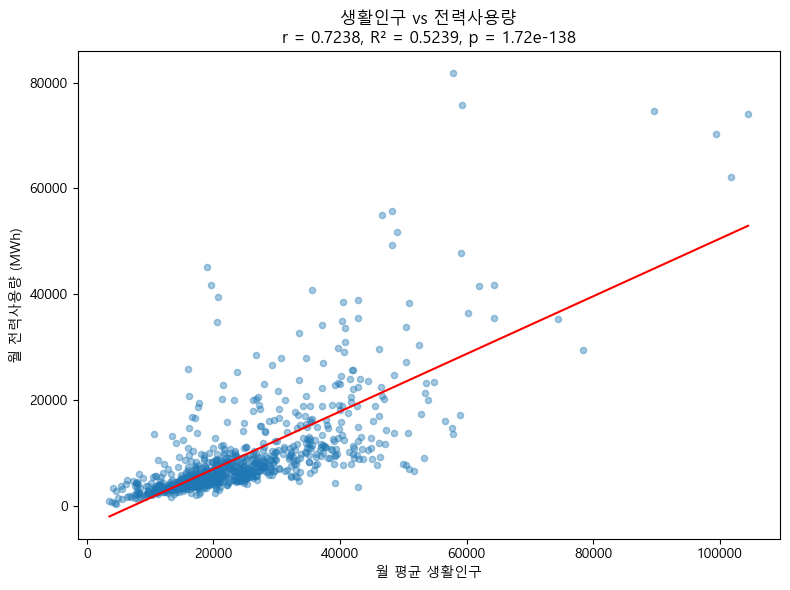

저장 완료


In [35]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy import stats

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 전체 상관관계
r, p = stats.pearsonr(corr_df["평균생활인구"], corr_df["전력사용량"])
print(f"피어슨 상관계수 r = {r:.4f}")
print(f"p-value = {p:.4e}")
print(f"결정계수 R² = {r**2:.4f}")

# 산점도
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(corr_df["평균생활인구"], corr_df["전력사용량"], alpha=0.4, s=20)

# 회귀선
m, b = np.polyfit(corr_df["평균생활인구"], corr_df["전력사용량"], 1)
x_line = np.linspace(corr_df["평균생활인구"].min(), corr_df["평균생활인구"].max(), 100)
ax.plot(x_line, m * x_line + b, color="red", linewidth=1.5)

ax.set_xlabel("월 평균 생활인구")
ax.set_ylabel("월 전력사용량 (MWh)")
ax.set_title(f"생활인구 vs 전력사용량\nr = {r:.4f}, R² = {r**2:.4f}, p = {p:.2e}")

plt.tight_layout()
plt.savefig(output_dir / "corr_population_power.png", dpi=150)
plt.show()
print("저장 완료")

- r = 0.72 → 강한 양의 상관관계
- p < 0.001 → 통계적으로 매우 유의미
- R² = 0.52 → 생활인구가 전력사용량 분산의 52% 설명

1. 이상치 존재:

생활인구 대비 전력이 지나치게 높은 점들이 보임 — 인구 40,000~60,000 수준인데 전력이 75,000~82,000 찍는 행정동들이 있음. 아마 대형 상업시설이나 업무지구일 것으로 보임

2. 회귀선이 음수 절편:

y절편이 음수로 내려가 있는데, 이건 인구 적은 지역에서 모델이 음의 전력을 예측한다는 의미라 물리적으로 말이 안됨

이상치 행정동 확인

In [36]:
# 전력사용량 상위 10개 행정동 확인
outliers = corr_df.nlargest(10, "전력사용량")[["자치구명", "행정동명", "월", "전력사용량", "평균생활인구"]]
print(outliers.to_string())

     자치구명   행정동명   월      전력사용량         평균생활인구
550   금천구    가산동   1  81784.374   57825.656921
551   금천구    가산동  12  75834.821   59313.854649
574  영등포구    여의동   1  74566.710   89664.663499
734   강남구   역삼1동   1  73966.727  104450.349019
575  영등포구    여의동  12  70214.589   99452.786607
735   강남구   역삼1동  12  62094.067  101676.038870
443   마포구    상암동  12  55722.228   48146.520205
442   마포구    상암동   1  54957.593   46669.189019
502   강서구  가양제1동   1  51694.893   49030.438826
503   강서구  가양제1동  12  49344.469   48175.324057


원인파악:

- 가산동 → 서울디지털산업단지. 공장/사무용 건물 밀집 → 인구 대비 전력 압도적으로 높음
- 여의동 → 여의도 금융업무지구. 대형 빌딩 밀집
- 역삼1동 → 강남 업무지구
- 상암동 → 미디어시티, 대형 방송국
- 가양제1동 → 대규모 아파트 단지

"생활인구만으로는 설명 안 되는 전력 과다 지역 = 업무/산업 특성 행정동" 

=> 업무, 산업, 사업체 기반 근거가 추가로 더 필요할듯

로그 변환 후 상관관계 재확인

로그변환 후 r = 0.7886
p-value = 7.7053e-181
R² = 0.6219


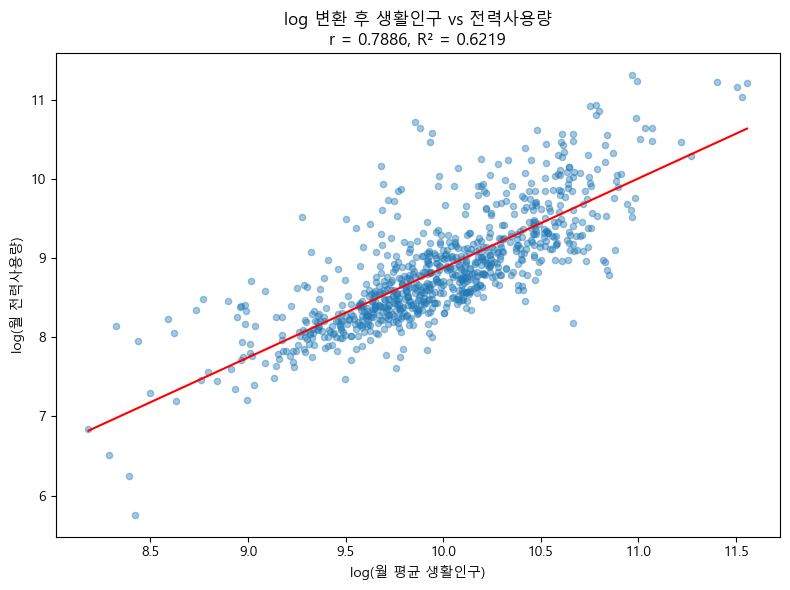

In [37]:
corr_df["log_전력"] = np.log(corr_df["전력사용량"])
corr_df["log_인구"] = np.log(corr_df["평균생활인구"])

r_log, p_log = stats.pearsonr(corr_df["log_인구"], corr_df["log_전력"])
print(f"로그변환 후 r = {r_log:.4f}")
print(f"p-value = {p_log:.4e}")
print(f"R² = {r_log**2:.4f}")

# 산점도
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(corr_df["log_인구"], corr_df["log_전력"], alpha=0.4, s=20)

m, b = np.polyfit(corr_df["log_인구"], corr_df["log_전력"], 1)
x_line = np.linspace(corr_df["log_인구"].min(), corr_df["log_인구"].max(), 100)
ax.plot(x_line, m * x_line + b, color="red", linewidth=1.5)

ax.set_xlabel("log(월 평균 생활인구)")
ax.set_ylabel("log(월 전력사용량)")
ax.set_title(f"log 변환 후 생활인구 vs 전력사용량\nr = {r_log:.4f}, R² = {r_log**2:.4f}")

plt.tight_layout()
plt.savefig(output_dir / "corr_log_population_power.png", dpi=150)
plt.show()

- r: 0.72 → 0.79 로 향상
- R²: 0.52 → 0.62 로 향상
- 그래프의 선형 패턴이 훨씬 깔끔해짐
- 음수 절편 문제 사라짐

>"행정동별 월 평균 생활인구와 전력사용량 간 로그 변환 후 피어슨 상관계수 r = 0.79 (R² = 0.62, p < 0.001)로 강한 양의 상관관계를 확인하였다. 이를 근거로 시간대별 생활인구 비율을 활용한 전력 배분의 통계적 타당성을 검증하였다."

최종 결과 저장

In [38]:
# 파일럿 결과 저장
result2.to_csv(output_dir / "pilot_hourly_power_2023.csv", index=False, encoding="utf-8-sig")
energy_long_clean.to_csv(output_dir / "energy_long_clean.csv", index=False, encoding="utf-8-sig")
pop_ratio.to_csv(output_dir / "pop_ratio_2023.csv", index=False, encoding="utf-8-sig")
corr_df.to_csv(output_dir / "corr_pilot_2023.csv", index=False, encoding="utf-8-sig")

print("저장 완료")
print(f"  - pilot_hourly_power_2023.csv : 시간대별 추정 전력 (파일럿)")
print(f"  - energy_long_clean.csv       : 전처리된 전력 데이터 (전체)")
print(f"  - pop_ratio_2023.csv          : 시간대별 생활인구 비율")
print(f"  - corr_pilot_2023.csv         : 상관관계 검증 데이터")

저장 완료
  - pilot_hourly_power_2023.csv : 시간대별 추정 전력 (파일럿)
  - energy_long_clean.csv       : 전처리된 전력 데이터 (전체)
  - pop_ratio_2023.csv          : 시간대별 생활인구 비율
  - corr_pilot_2023.csv         : 상관관계 검증 데이터


시간대별 비율 시각화

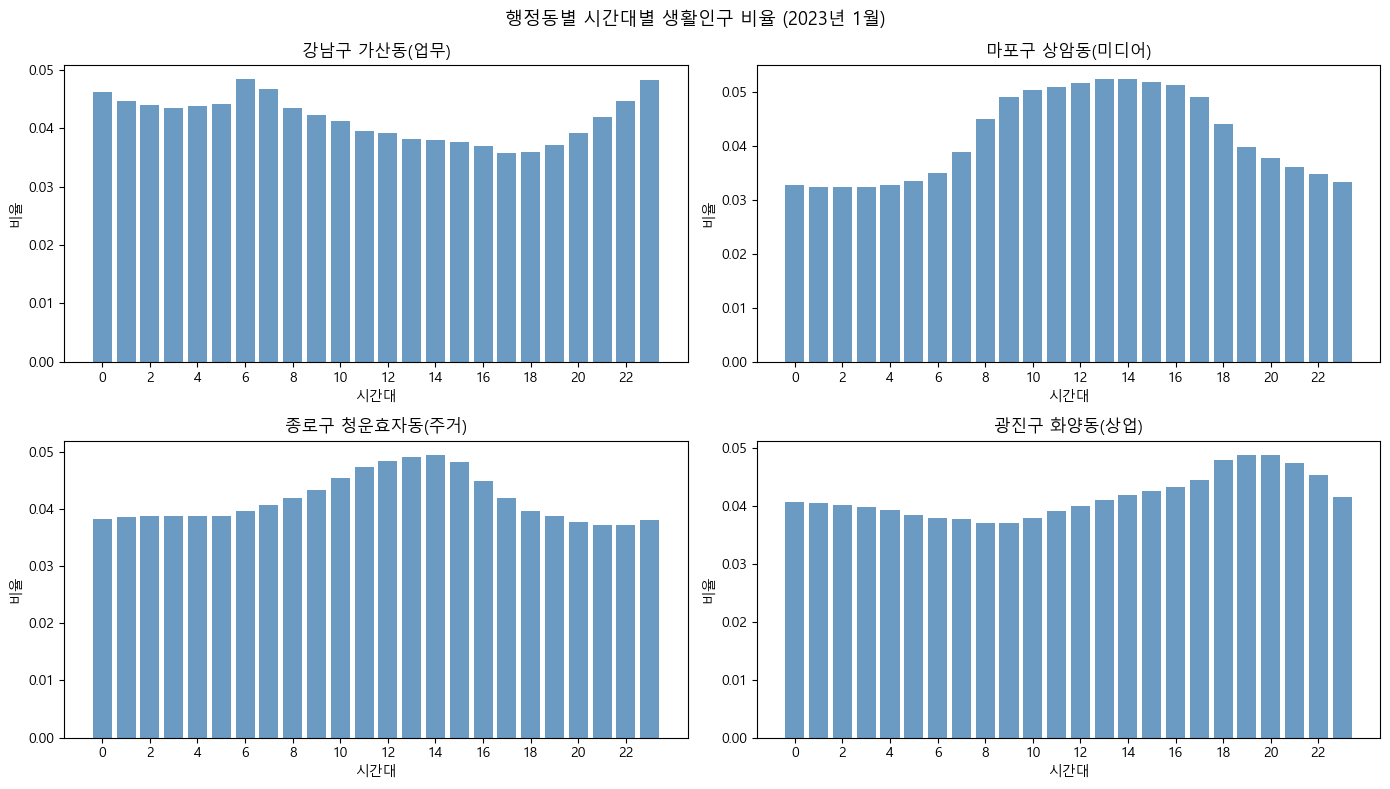

In [41]:
# 대표 행정동 4개 선택 (업무/주거/상업/혼합)
sample_dongs = {
    "11680660": "강남구 가산동(업무)",   # 가산동
    "11440740": "마포구 상암동(미디어)",  # 상암동
    "11110515": "종로구 청운효자동(주거)", # 청운효자동
    "11215710": "광진구 화양동(상업)",    # 화양동
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, (code, name) in enumerate(sample_dongs.items()):
    df_dong = pop_ratio[
        (pop_ratio["행정동코드"] == code) &
        (pop_ratio["연도"] == 2023) &
        (pop_ratio["월"] == 1)
    ].sort_values("시간대구분")
    
    if len(df_dong) == 0:
        axes[i].set_title(f"{name} - 데이터 없음")
        continue
    
    axes[i].bar(df_dong["시간대구분"], df_dong["시간대비율"], color="steelblue", alpha=0.8)
    axes[i].set_title(name)
    axes[i].set_xlabel("시간대")
    axes[i].set_ylabel("비율")
    axes[i].set_xticks(range(0, 24, 2))

plt.suptitle("행정동별 시간대별 생활인구 비율 (2023년 1월)", fontsize=13)
plt.tight_layout()
plt.savefig(output_dir / "hourly_ratio_sample.png", dpi=150)
plt.show()

파일럿 -> 2023+2024 데이터로 확장

In [42]:
# population 폴더 파일 목록 확인
pop_files = sorted(list(POP_DIR.glob("*.csv")))
print(f"총 파일 수: {len(pop_files)}개")
for f in pop_files:
    print(f.name)

총 파일 수: 24개
LOCAL_PEOPLE_DONG_202301.csv
LOCAL_PEOPLE_DONG_202302.csv
LOCAL_PEOPLE_DONG_202303.csv
LOCAL_PEOPLE_DONG_202304.csv
LOCAL_PEOPLE_DONG_202305.csv
LOCAL_PEOPLE_DONG_202306.csv
LOCAL_PEOPLE_DONG_202307.csv
LOCAL_PEOPLE_DONG_202308.csv
LOCAL_PEOPLE_DONG_202309.csv
LOCAL_PEOPLE_DONG_202310.csv
LOCAL_PEOPLE_DONG_202311.csv
LOCAL_PEOPLE_DONG_202312.csv
LOCAL_PEOPLE_DONG_202401.csv
LOCAL_PEOPLE_DONG_202402.csv
LOCAL_PEOPLE_DONG_202403.csv
LOCAL_PEOPLE_DONG_202404.csv
LOCAL_PEOPLE_DONG_202405.csv
LOCAL_PEOPLE_DONG_202406.csv
LOCAL_PEOPLE_DONG_202407.csv
LOCAL_PEOPLE_DONG_202408.csv
LOCAL_PEOPLE_DONG_202409.csv
LOCAL_PEOPLE_DONG_202410.csv
LOCAL_PEOPLE_DONG_202411.csv
LOCAL_PEOPLE_DONG_202412.csv


전체 생활인구 로드

In [ ]:
use_cols = ["기준일ID", "시간대구분", "행정동코드", "총생활인구수"]

pop_all_list = []
for f in pop_files:
    df = pd.read_csv(f, encoding="utf-8", index_col=False, usecols=use_cols)
    pop_all_list.append(df)
    print(f"{f.name} 로드 완료: {len(df)}행")

pop_all = pd.concat(pop_all_list, ignore_index=True)

# 타입 정리
pop_all["행정동코드"] = pop_all["행정동코드"].astype(int).astype(str)
pop_all["기준일ID"] = pop_all["기준일ID"].astype(str)
pop_all["연도"] = pop_all["기준일ID"].str[:4].astype(int)
pop_all["월"] = pop_all["기준일ID"].str[4:6].astype(int)

LOCAL_PEOPLE_DONG_202301.csv 로드 완료: 315456행
LOCAL_PEOPLE_DONG_202302.csv 로드 완료: 284928행
LOCAL_PEOPLE_DONG_202303.csv 로드 완료: 315456행
LOCAL_PEOPLE_DONG_202304.csv 로드 완료: 305280행
LOCAL_PEOPLE_DONG_202305.csv 로드 완료: 315456행
LOCAL_PEOPLE_DONG_202306.csv 로드 완료: 305280행
LOCAL_PEOPLE_DONG_202307.csv 로드 완료: 315456행
LOCAL_PEOPLE_DONG_202308.csv 로드 완료: 315456행
LOCAL_PEOPLE_DONG_202309.csv 로드 완료: 305280행
LOCAL_PEOPLE_DONG_202310.csv 로드 완료: 315456행
LOCAL_PEOPLE_DONG_202311.csv 로드 완료: 305280행
LOCAL_PEOPLE_DONG_202312.csv 로드 완료: 315456행
LOCAL_PEOPLE_DONG_202401.csv 로드 완료: 315456행
LOCAL_PEOPLE_DONG_202402.csv 로드 완료: 295104행
LOCAL_PEOPLE_DONG_202403.csv 로드 완료: 315456행
LOCAL_PEOPLE_DONG_202404.csv 로드 완료: 305280행
LOCAL_PEOPLE_DONG_202405.csv 로드 완료: 315456행
LOCAL_PEOPLE_DONG_202406.csv 로드 완료: 305280행
LOCAL_PEOPLE_DONG_202407.csv 로드 완료: 315456행
LOCAL_PEOPLE_DONG_202408.csv 로드 완료: 315456행
LOCAL_PEOPLE_DONG_202409.csv 로드 완료: 305280행
LOCAL_PEOPLE_DONG_202410.csv 로드 완료: 315456행
LOCAL_PEOPLE_DONG_202411.csv 로드 

In [44]:
print(pop_all.shape)
print(f"연도 범위: {pop_all['연도'].unique()}")
print(f"월 범위: {pop_all['월'].unique()}")

(7438656, 6)
연도 범위: [2023 2024]
월 범위: [ 1  2  3  4  5  6  7  8  9 10 11 12]


전체 시간대 비율 계산

In [45]:
# 행정동별 월별 시간대별 합산
pop_all_hourly = pop_all.groupby(["행정동코드", "연도", "월", "시간대구분"])["총생활인구수"].sum().reset_index()

# 행정동별 월별 전체 합산
pop_all_monthly = pop_all_hourly.groupby(["행정동코드", "연도", "월"])["총생활인구수"].sum().reset_index()
pop_all_monthly.columns = ["행정동코드", "연도", "월", "월별총인구"]

# 비율 계산
pop_all_ratio = pop_all_hourly.merge(pop_all_monthly, on=["행정동코드", "연도", "월"])
pop_all_ratio["시간대비율"] = pop_all_ratio["총생활인구수"] / pop_all_ratio["월별총인구"]

# 검증
print(f"shape: {pop_all_ratio.shape}")
print(f"비율 합계 검증:")
print(pop_all_ratio.groupby(["행정동코드", "연도", "월"])["시간대비율"].sum().describe())

shape: (244224, 7)
비율 합계 검증:
count    1.017600e+04
mean     1.000000e+00
std      3.957695e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: 시간대비율, dtype: float64


전체 전력 데이터와 조인

In [28]:
# 2023~2024년 전력 데이터 필터링
energy_2324 = energy_long_clean[
    energy_long_clean["연도"].isin([2023, 2024])
].copy()

# 조인
result_all = energy_2324.merge(
    pop_all_ratio[["행정동코드", "연도", "월", "시간대구분", "시간대비율"]],
    on=["행정동코드", "연도", "월"],
    how="left"
)

# 시간대별 전력 추정
result_all["추정전력"] = result_all["전력사용량"] * result_all["시간대비율"]

# 검증
print(f"shape: {result_all.shape}")
print(f"결측치: {result_all['추정전력'].isna().sum()}행")

# 오차 검증
verify_all = result_all.groupby(["행정동코드", "연도", "월"]).agg(
    원래전력=("전력사용량", "first"),
    추정전력합계=("추정전력", "sum")
).reset_index()
verify_all["차이"] = (verify_all["추정전력합계"] - verify_all["원래전력"]).abs()
print(f"최대 오차: {verify_all['차이'].max():.10f}")
print(f"평균 오차: {verify_all['차이'].mean():.10f}")

shape: (244224, 9)
결측치: 0행
최대 오차: 0.0000000000
평균 오차: 0.0000000000


전력 소비 밀도 지표(전력효율지표) 계산 및 저장

> 전력 소비 밀도 지표 = 전력사용량 / 생활인구

해석:

값 ↑ → 인구 대비 전력을 많이 씀 → 비효율 / 과다 사용 지역 → 전력 소비 밀도가 높음

값 ↓ → 인구 대비 전력을 적게 씀 → 상대적 잉여 가능성 있는 지역  → 전력 소비 밀도가 낮음

- 수요집중 지역 = 전력 소비 밀도 높음 (인구 대비 전력 많이 씀)
- 잉여가능 지역 = 전력 소비 밀도 낮음 (인구 대비 전력 적게 씀)

=> 이 지표로 수요 집중 지역 vs 잉여 전력 지역을 구분하는 기준이 됨. 

나중에 재분배 타겟 선정할 때 핵심 변수로 사용가능

가산동 같은 산업단지는 값이 높게 나오고, 주거 중심 동네는 낮게 나올 것으로 예상됨

In [29]:
# 행정동별 월별 평균 생활인구 계산
pop_all_avg = pop_all.groupby(["행정동코드", "연도", "월"])["총생활인구수"].mean().reset_index()
pop_all_avg.columns = ["행정동코드", "연도", "월", "평균생활인구"]

# 전력 효율 지표 계산 (전력/인구)
efficiency = energy_2324.merge(pop_all_avg, on=["행정동코드", "연도", "월"], how="left")
efficiency["전력효율지표"] = efficiency["전력사용량"] / efficiency["평균생활인구"]

print(efficiency[["자치구명", "행정동명", "연도", "월", "전력사용량", "평균생활인구", "전력효율지표"]].head(10))

# 저장
result_all.to_csv(output_dir / "hourly_power_2023_2024.csv", index=False, encoding="utf-8-sig")
efficiency.to_csv(output_dir / "efficiency_2023_2024.csv", index=False, encoding="utf-8-sig")
pop_all_ratio.to_csv(output_dir / "pop_ratio_all.csv", index=False, encoding="utf-8-sig")

print("\n저장 완료")

  자치구명   행정동명    연도   월     전력사용량        평균생활인구    전력효율지표
0  종로구  청운효자동  2023   1  4225.082  16648.452199  0.253782
1  종로구  청운효자동  2023   2  3887.327  17246.679426  0.225396
2  종로구  청운효자동  2023   3  3056.376  18490.636366  0.165293
3  종로구  청운효자동  2023   4  2848.263  18586.757700  0.153242
4  종로구  청운효자동  2023   5  2624.542  18551.474625  0.141473
5  종로구  청운효자동  2023   6  2891.552  17800.885216  0.162439
6  종로구  청운효자동  2023   7  3405.131  16290.124041  0.209030
7  종로구  청운효자동  2023   8  4030.694  16296.311332  0.247338
8  종로구  청운효자동  2023   9  3771.483  17845.275959  0.211343
9  종로구  청운효자동  2023  10  2752.241  18327.989952  0.150166

저장 완료


수요/공급 지역 분류

In [48]:
# 행정동별 평균 전력효율지표 계산 (2023~2024 전체 평균)
efficiency_avg = efficiency.groupby(["행정동코드", "자치구명", "행정동명"]).agg(
    평균전력사용량=("전력사용량", "mean"),
    평균생활인구=("평균생활인구", "mean"),
    평균전력효율지표=("전력효율지표", "mean")
).reset_index()

# 분위수 기준으로 분류
q33 = efficiency_avg["평균전력효율지표"].quantile(0.33)
q67 = efficiency_avg["평균전력효율지표"].quantile(0.67)

print(f"하위 33% 기준값: {q33:.4f}")
print(f"상위 33% 기준값: {q67:.4f}")

def classify(x):
    if x >= q67:
        return "수요집중"
    elif x <= q33:
        return "잉여가능"
    else:
        return "중간"

efficiency_avg["지역분류"] = efficiency_avg["평균전력효율지표"].apply(classify)

print(efficiency_avg["지역분류"].value_counts())
print(efficiency_avg.sort_values("평균전력효율지표", ascending=False).head(10)[["자치구명", "행정동명", "평균전력효율지표", "지역분류"]])

하위 33% 기준값: 0.2529
상위 33% 기준값: 0.3216
지역분류
중간      144
잉여가능    140
수요집중    140
Name: count, dtype: int64
    자치구명    행정동명  평균전력효율지표  지역분류
64   성동구     용답동  2.230000  수요집중
351  서초구    방배2동  1.802509  수요집중
261  구로구   구로제1동  1.305970  수요집중
275  금천구     가산동  1.230815  수요집중
37   용산구  원효로제2동  1.184868  수요집중
221  마포구     상암동  1.141975  수요집중
251  강서구   가양제1동  1.048778  수요집중
19    중구      명동  1.031715  수요집중
17    중구     소공동  0.962114  수요집중
222  양천구     목1동  0.950715  수요집중


- 용답동, 구로1동, 가산동 → 산업/공장 지역. 인구 대비 전력 압도적
- 방배2동 → 특이하네. 주거지역인데 높음. 나중에 확인 필요
- 상암동, 명동, 소공동 → 업무/상업 지역. 예상대로

잉여 지역 확인 및 최종 저장

In [49]:
# 잉여 가능 지역 top 10
print("=== 잉여 가능 지역 (전력효율 낮음) ===")
print(efficiency_avg.sort_values("평균전력효율지표", ascending=True).head(10)[
    ["자치구명", "행정동명", "평균전력효율지표", "평균생활인구", "지역분류"]
].to_string())

# 최종 저장
efficiency_avg.to_csv(output_dir / "efficiency_classified.csv", index=False, encoding="utf-8-sig")
print("\n저장 완료")

=== 잉여 가능 지역 (전력효율 낮음) ===
     자치구명    행정동명  평균전력효율지표        평균생활인구  지역분류
422   강동구   둔촌제1동  0.049969   5020.405257  잉여가능
193  서대문구    북아현동  0.086654  42818.359732  잉여가능
174   노원구    상계9동  0.112160  17002.827425  잉여가능
406   강동구     강일동  0.130345  50903.547834  잉여가능
371   강남구    개포1동  0.133128  15934.082522  잉여가능
134   강북구    삼각산동  0.139099  19627.759497  잉여가능
163   노원구    하계2동  0.145812  16083.095007  잉여가능
344   서초구    반포본동  0.145915   4475.857757  잉여가능
170   노원구  상계3.4동  0.150096  20202.420835  잉여가능
250   강서구   화곡제8동  0.155351  33006.032688  잉여가능

저장 완료


- 둔촌제1동, 반포본동 → 생활인구 적은데 잉여 → 재건축/공사 중인 지역일 가능성
- 상계9동, 하계2동, 상계3.4동 → 노원구 주거 밀집지역. 인구 많은데 전력 효율 낮음 → 순수 주거형
- 북아현동, 강일동 → 대규모 아파트 단지

### 전체흐름

전력 데이터 (월별) 

→ 생활인구 시간대 비율 적용 

→ 시간대별 전력 추정 (r=0.79 검증)

→ 전력효율지표 계산

→ 수요집중 140개 / 중간 144개 / 잉여가능 140개 분류 완료

---

**2022.6 ~ 2025.5 (최근36개월)** 시간대 전력추정 데이터셋 

전체 36개월 로드

In [4]:
use_cols = ["기준일ID", "시간대구분", "행정동코드", "총생활인구수"]

pop_all_list = []
for f in pop_files_all:
    df = pd.read_csv(f, encoding="utf-8", index_col=False, usecols=use_cols)
    pop_all_list.append(df)
    print(f"{f.name} 로드 완료: {len(df)}행")

pop_all = pd.concat(pop_all_list, ignore_index=True)

pop_all["행정동코드"] = pop_all["행정동코드"].astype(int).astype(str)
pop_all["기준일ID"] = pop_all["기준일ID"].astype(str)
pop_all["연도"] = pop_all["기준일ID"].str[:4].astype(int)
pop_all["월"] = pop_all["기준일ID"].str[4:6].astype(int)

print(f"\n전체 shape: {pop_all.shape}")
print(f"연도 범위: {sorted(pop_all['연도'].unique())}")
print(f"월 범위: {sorted(pop_all['월'].unique())}")

LOCAL_PEOPLE_DONG_202206.csv 로드 완료: 305280행
LOCAL_PEOPLE_DONG_202207.csv 로드 완료: 315456행
LOCAL_PEOPLE_DONG_202208.csv 로드 완료: 315456행
LOCAL_PEOPLE_DONG_202209.csv 로드 완료: 305280행
LOCAL_PEOPLE_DONG_202210.csv 로드 완료: 315456행
LOCAL_PEOPLE_DONG_202211.csv 로드 완료: 305280행
LOCAL_PEOPLE_DONG_202212.csv 로드 완료: 315456행
LOCAL_PEOPLE_DONG_202301.csv 로드 완료: 315456행
LOCAL_PEOPLE_DONG_202302.csv 로드 완료: 284928행
LOCAL_PEOPLE_DONG_202303.csv 로드 완료: 315456행
LOCAL_PEOPLE_DONG_202304.csv 로드 완료: 305280행
LOCAL_PEOPLE_DONG_202305.csv 로드 완료: 315456행
LOCAL_PEOPLE_DONG_202306.csv 로드 완료: 305280행
LOCAL_PEOPLE_DONG_202307.csv 로드 완료: 315456행
LOCAL_PEOPLE_DONG_202308.csv 로드 완료: 315456행
LOCAL_PEOPLE_DONG_202309.csv 로드 완료: 305280행
LOCAL_PEOPLE_DONG_202310.csv 로드 완료: 315456행
LOCAL_PEOPLE_DONG_202311.csv 로드 완료: 305280행
LOCAL_PEOPLE_DONG_202312.csv 로드 완료: 315456행
LOCAL_PEOPLE_DONG_202401.csv 로드 완료: 315456행
LOCAL_PEOPLE_DONG_202402.csv 로드 완료: 295104행
LOCAL_PEOPLE_DONG_202403.csv 로드 완료: 315456행
LOCAL_PEOPLE_DONG_202404.csv 로드 

전체 시간대 비율 계산

In [5]:
# 행정동별 월별 시간대별 합산
pop_all_hourly = pop_all.groupby(["행정동코드", "연도", "월", "시간대구분"])["총생활인구수"].sum().reset_index()

# 행정동별 월별 전체 합산
pop_all_monthly = pop_all_hourly.groupby(["행정동코드", "연도", "월"])["총생활인구수"].sum().reset_index()
pop_all_monthly.columns = ["행정동코드", "연도", "월", "월별총인구"]

# 비율 계산
pop_all_ratio = pop_all_hourly.merge(pop_all_monthly, on=["행정동코드", "연도", "월"])
pop_all_ratio["시간대비율"] = pop_all_ratio["총생활인구수"] / pop_all_ratio["월별총인구"]

# 검증
print(f"shape: {pop_all_ratio.shape}")
check = pop_all_ratio.groupby(["행정동코드", "연도", "월"])["시간대비율"].sum().describe()
print(f"비율 합계 검증:\n{check}")

shape: (366336, 7)
비율 합계 검증:
count    1.526400e+04
mean     1.000000e+00
std      3.991663e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: 시간대비율, dtype: float64


전력 데이터 36개월 필터링 및 조인

In [25]:
# 2022.6 ~ 2025.5 전력 데이터 필터링
energy_36m = energy_long_clean[
    ((energy_long_clean["연도"] == 2022) & (energy_long_clean["월"] >= 6)) |
    ((energy_long_clean["연도"] == 2023)) |
    ((energy_long_clean["연도"] == 2024)) |
    ((energy_long_clean["연도"] == 2025) & (energy_long_clean["월"] <= 5))
].copy()

print(f"전력 데이터 shape: {energy_36m.shape}")
print(f"연도별 건수:\n{energy_36m.groupby('연도')['월'].nunique()}")

# 조인
result_36m = energy_36m.merge(
    pop_all_ratio[["행정동코드", "연도", "월", "시간대구분", "시간대비율"]],
    on=["행정동코드", "연도", "월"],
    how="left"
)

# 시간대별 전력 추정
result_36m["추정전력"] = result_36m["전력사용량"] * result_36m["시간대비율"]

# 검증
print(f"\n결과 shape: {result_36m.shape}")
print(f"결측치: {result_36m['추정전력'].isna().sum()}행")

verify = result_36m.groupby(["행정동코드", "연도", "월"]).agg(
    원래전력=("전력사용량", "first"),
    추정전력합계=("추정전력", "sum")
).reset_index()
verify["차이"] = (verify["추정전력합계"] - verify["원래전력"]).abs()
print(f"최대 오차: {verify['차이'].max():.10f}")

전력 데이터 shape: (15264, 6)
연도별 건수:
연도
2022     7
2023    12
2024    12
2025     5
Name: 월, dtype: int64

결과 shape: (366336, 9)
결측치: 0행
최대 오차: 0.0000000000


최종 저장

In [26]:
# 전력 효율 지표 계산
pop_all_avg = pop_all.groupby(["행정동코드", "연도", "월"])["총생활인구수"].mean().reset_index()
pop_all_avg.columns = ["행정동코드", "연도", "월", "평균생활인구"]

efficiency_36m = energy_36m.merge(pop_all_avg, on=["행정동코드", "연도", "월"], how="left")
efficiency_36m["전력효율지표"] = efficiency_36m["전력사용량"] / efficiency_36m["평균생활인구"]

# 행정동별 평균 전력효율지표 + 지역분류
efficiency_avg_36m = efficiency_36m.groupby(["행정동코드", "자치구명", "행정동명"]).agg(
    평균전력사용량=("전력사용량", "mean"),
    평균생활인구=("평균생활인구", "mean"),
    평균전력효율지표=("전력효율지표", "mean")
).reset_index()

q33 = efficiency_avg_36m["평균전력효율지표"].quantile(0.33)
q67 = efficiency_avg_36m["평균전력효율지표"].quantile(0.67)

def classify(x):
    if x >= q67:
        return "수요집중"
    elif x <= q33:
        return "잉여가능"
    else:
        return "중간"

efficiency_avg_36m["지역분류"] = efficiency_avg_36m["평균전력효율지표"].apply(classify)

# 저장
result_36m.to_csv(output_dir / "hourly_power_36m.csv", index=False, encoding="utf-8-sig")
efficiency_36m.to_csv(output_dir / "efficiency_36m.csv", index=False, encoding="utf-8-sig")
efficiency_avg_36m.to_csv(output_dir / "node_list.csv", index=False, encoding="utf-8-sig")
pop_all_ratio.to_csv(output_dir / "pop_ratio_36m.csv", index=False, encoding="utf-8-sig")

print("저장 완료")
print(f"\n지역분류 현황:\n{efficiency_avg_36m['지역분류'].value_counts()}")
print(f"\n수요집중 top 10:")
print(efficiency_avg_36m.sort_values("평균전력효율지표", ascending=False).head(10)[
    ["자치구명", "행정동명", "평균전력효율지표", "지역분류"]
].to_string())

저장 완료

지역분류 현황:
지역분류
중간      144
잉여가능    140
수요집중    140
Name: count, dtype: int64

수요집중 top 10:
    자치구명    행정동명  평균전력효율지표  지역분류
64   성동구     용답동  2.249909  수요집중
351  서초구    방배2동  1.806585  수요집중
261  구로구   구로제1동  1.308480  수요집중
275  금천구     가산동  1.244328  수요집중
37   용산구  원효로제2동  1.158979  수요집중
221  마포구     상암동  1.149824  수요집중
251  강서구   가양제1동  1.042450  수요집중
19    중구      명동  1.026577  수요집중
222  양천구     목1동  0.982063  수요집중
17    중구     소공동  0.963746  수요집중


지역분류 기준:

**임의로** 상위 1/3을 수요집중, 하위 1/3을 잉여가능, 나머지를 중간"으로 균등하게 3등분한 거임

=> 수요집중 140개, 중간 144개, 잉여가능 140개로 거의 균등하게 나옴

완성된 산출물:

- hourly_power_36m.csv → 행정동별 시간대별 추정전력 (366,336행)

- efficiency_36m.csv → 행정동별 월별 전력효율지표

- node_list.csv → 최종 노드 리스트 424개 (수요집중/중간/잉여가능 분류)

- pop_ratio_36m.csv → 시간대별 생활인구 비율

의문점: 방배2동은 단순 거주지역같은데 전력효율이 왤케 높지??

In [30]:
check = efficiency_36m[
    (efficiency_36m["자치구명"] == "서초구") &
    (efficiency_36m["행정동명"] == "방배2동")
][["연도", "월", "전력사용량", "평균생활인구", "전력효율지표"]].sort_values(["연도", "월"])

print(check.to_string())

         연도   월      전력사용량        평균생활인구    전력효율지표
12636  2022   6  33326.383  21050.598362  1.583156
12637  2022   7  39965.479  20682.839509  1.932301
12638  2022   8  44181.329  20199.843883  2.187211
12639  2022   9  38595.479  20164.198397  1.914060
12640  2022  10  32519.728  20576.559545  1.580426
12641  2022  11  32803.866  21364.607125  1.535430
12642  2022  12  35235.475  21488.498675  1.639736
12643  2023   1  39468.424  20771.212742  1.900150
12644  2023   2  38430.940  21458.193991  1.790968
12645  2023   3  32139.373  21348.002364  1.505498
12646  2023   4  32029.622  21024.527050  1.523441
12647  2023   5  31861.097  20413.253465  1.560804
12648  2023   6  33599.113  20706.008880  1.622675
12649  2023   7  39354.700  20569.325963  1.913271
12650  2023   8  44006.966  20708.021464  2.125117
12651  2023   9  41955.510  20511.379698  2.045475
12652  2023  10  32473.377  19778.221144  1.641876
12653  2023  11  33109.637  20205.983585  1.638606
12654  2023  12  34851.978  205

In [31]:
check2 = efficiency_36m[
    (efficiency_36m["자치구명"] == "성동구") &
    (efficiency_36m["행정동명"] == "용답동")
][["연도", "월", "전력사용량", "평균생활인구", "전력효율지표"]].sort_values(["연도", "월"])

print(check2.to_string())

        연도   월      전력사용량        평균생활인구    전력효율지표
2304  2022   6  39947.440  19963.949164  2.000979
2305  2022   7  46693.075  19295.699576  2.419870
2306  2022   8  52677.947  19173.716321  2.747404
2307  2022   9  45670.222  19417.175260  2.352053
2308  2022  10  39148.839  19444.860777  2.013326
2309  2022  11  39401.753  19660.608379  2.004096
2310  2022  12  41195.702  19299.646223  2.134531
2311  2023   1  45183.494  19039.864720  2.373100
2312  2023   2  44493.504  19805.093946  2.246569
2313  2023   3  37625.853  19878.866320  1.892756
2314  2023   4  38446.833  19709.476825  1.950678
2315  2023   5  37478.344  19610.367765  1.911149
2316  2023   6  40351.224  19542.633483  2.064779
2317  2023   7  45173.848  19453.770503  2.322113
2318  2023   8  53439.490  19839.542478  2.693585
2319  2023   9  49496.982  20237.161163  2.445846
2320  2023  10  38990.918  19839.430999  1.965324
2321  2023  11  40546.624  19773.265519  2.050578
2322  2023  12  41671.297  19543.658176  2.132216


이상치 검토 결론:

수요집중 상위 지역들이 전부 실제 특성을 반영하고 있음

- 용답동 → 공업/제조 지역
- 방배2동 → 법조타운 (대형 공공업무시설)
- 구로1동, 가산동 → 산업단지
- 상암동 → 미디어 업무지구
- 명동, 소공동 → 상업 밀집지

In [32]:
import os
for f in output_dir.glob("*.csv"):
    size_mb = os.path.getsize(f) / (1024*1024)
    print(f"{f.name}: {size_mb:.1f} MB")

corr_pilot_2023.csv: 0.1 MB
efficiency_2023_2024.csv: 0.8 MB
efficiency_36m.csv: 1.3 MB
efficiency_classified.csv: 0.0 MB
energy_long_clean.csv: 1.9 MB
hourly_power_2023_2024.csv: 21.0 MB
hourly_power_36m.csv: 31.5 MB
node_list.csv: 0.0 MB
pilot_hourly_power_2023.csv: 1.8 MB
pop_ratio_2023.csv: 1.3 MB
pop_ratio_36m.csv: 23.3 MB
pop_ratio_all.csv: 23.3 MB
